In [ ]:
###Práctica Módulo 2: NLP

In [ ]:
%run func_aux.py

In [ ]:
#comenzamos importando las funciones auxiliares (las cuales necesitaremos a lo largo de la práctica)
import func_aux as fa

In [ ]:
###MODELO 1: MODELO BASADO EN LA PREDICCIÓN DE PALABRAS

###LO PRIMERO QUE TENEMOS QUE HACER ES CARGAR LOS TEXTOS DEL AULA VIRTUAL Y TOKENIZARLOS MEDIANTE LA FUNCIÓN AUXILIAR CARGAR_TOKENIZADOR,
# UNA VEZ CARGADOS LOS TEXTOS Y TOKENIZADOS, ALMACENAMOS LOS RESULTADOS EN VARIOS DICCIONARIOS, EN LOS CUALES LA CLAVE SERÁ EL NOMBRE DEL TEXTO
# Y EL VALOR SERÁ UNO DE LOS RESULTADOS DEVUELTOS POR LA FUNCIÓN CARGAR_TOKENIZADOR

paths = paths = {"juego de tronos": "/content/game_of_thrones.txt",
                 "harry potter": "/content/harry_potter_and_the_philosophers_stone.txt",
                 "el señor de los anillos": "/content/the_fellowship_of_the_ring.txt"
}


def procesar_textos(paths):
    tokenizer_dict = {}
    word_index_dict = {}
    sequences_dict = {}
    vocab_size_dict = {}

    for titulo, path in paths.items():
        tokenizador, secuencia, word_index, vocab_size = fa.carga_tokenizador(path)
        tokenizer_dict[titulo] = tokenizador
        sequences_dict[titulo] = secuencia
        word_index_dict[titulo] = word_index
        vocab_size_dict[titulo] = vocab_size

    return tokenizer_dict, word_index_dict, sequences_dict, vocab_size_dict

# Llamamos a la función
tokenizer_dict, word_index_dict, sequences_dict, vocab_size_dict = procesar_textos(paths)

for titulo in paths.keys():
    print(f"--- {titulo.upper()} ---")

    print(f"Vocabulario (tamaño): {vocab_size_dict[titulo]}")

    # Mostrar las primeras 10 palabras y sus tokens
    print("Primeras 10 palabras en word_index:")
    for palabra, token in list(word_index_dict[titulo].items())[:10]:
        print(f"  {palabra}: {token}")

    # Mostrar los primeros 10 tokens del texto
    print("Primeros 10 tokens en sequences:")
    print(sequences_dict[titulo][:10])

    print("\n")




--- JUEGO DE TRONOS ---
Vocabulario (tamaño): 7479
Primeras 10 palabras en word_index:
  the: 1
  and: 2
  a: 3
  to: 4
  of: 5
  he: 6
  his: 7
  was: 8
  her: 9
  in: 10
Primeros 10 tokens en sequences:
[78, 33, 3, 95, 271, 101, 153, 504, 763, 53]


--- HARRY POTTER ---
Vocabulario (tamaño): 6027
Primeras 10 palabras en word_index:
  the: 1
  and: 2
  to: 3
  a: 4
  he: 5
  of: 6
  harry: 7
  was: 8
  it: 9
  in: 10
Primeros 10 tokens en sequences:
[7, 123, 2, 1, 631, 155, 607, 38, 1, 140]


--- EL SEÑOR DE LOS ANILLOS ---
Vocabulario (tamaño): 8919
Primeras 10 palabras en word_index:
  the: 1
  and: 2
  of: 3
  to: 4
  a: 5
  he: 6
  in: 7
  i: 8
  it: 9
  that: 10
Primeros 10 tokens en sequences:
[64, 163, 112, 362, 3, 385, 125, 3167, 10, 6]




In [ ]:
###Ahora vamos a apoyarnos en otra función auxiliar para crear las ventanas deslizantes

# Tamaño de la ventana deslizante
n = 5

# Diccionario donde se almacenarán las palabras de entrada (input_contexts) y las palabras de salida (output_words)
input_output_dict = {}

# Iteramos sobre cada texto tokenizado (secuencia) en el diccionario 'sequences_dict'
for titulo, secuencia in sequences_dict.items():
    # Llamamos a la función 'crear_ventana' para generar los pares de entrada y salida
    # Esta función nos da 'input_contexts' (contexto) y 'output_words' (palabra objetivo)
    input_contexts, output_words = fa.crear_ventana(secuencia, n)

    # Almacenamos los resultados (input_contexts y output_words) en el diccionario 'input_output_dict'
    input_output_dict[titulo] = [input_contexts, output_words]

# Ahora, vamos a mostrar los resultados de 'crear_ventana' para cada texto
# Iteramos sobre el diccionario 'input_output_dict' para imprimir los resultados por texto
for input_output_dict_key, (input_contexts, output_words) in input_output_dict.items():
    # Imprimimos el título del texto en mayúsculas (input_output_dict_key es el nombre del texto)
    print(f"--- {input_output_dict_key.upper()} ---")

    # Mostramos las primeros 10 listas de entrada (contexto) generados para este texto
    print(f"input contexts: {input_contexts[:10]}")

    # Mostramos las primeras 10 palabras de salida (target words) generadas para este texto
    print(f"output words: {output_words[:10]}")


### Realmente esta celsa no estoy haciendo nada que vaya a usar después, pero nos ayuda
### a visualizar que es lo que hacemos cuando llamamos a esta función para crear ventanas
### y como se ve el output


--- JUEGO DE TRONOS ---
input contexts: [[  78   33   95  271]
 [  33    3  271  101]
 [   3   95  101  153]
 [  95  271  153  504]
 [ 271  101  504  763]
 [ 101  153  763   53]
 [ 153  504   53  953]
 [ 504  763  953  356]
 [ 763   53  356  691]
 [  53  953  691 1010]]
output words: [  3  95 271 101 153 504 763  53 953 356]
--- HARRY POTTER ---
input contexts: [[   7  123    1  631]
 [ 123    2  631  155]
 [   2    1  155  607]
 [   1  631  607   38]
 [ 631  155   38    1]
 [ 155  607    1  140]
 [ 607   38  140   73]
 [  38    1   73 1036]
 [   1  140 1036  144]
 [ 140   73  144    2]]
output words: [   2    1  631  155  607   38    1  140   73 1036]
--- EL SEÑOR DE LOS ANILLOS ---
input contexts: [[  64  163  362    3]
 [ 163  112    3  385]
 [ 112  362  385  125]
 [ 362    3  125 3167]
 [   3  385 3167   10]
 [ 385  125   10    6]
 [ 125 3167    6   55]
 [3167   10   55 5198]
 [  10    6 5198   30]
 [   6   55   30 5199]]
output words: [ 112  362    3  385  125 3167   10    6   55 

In [ ]:
#Probar hiperparámetros
# Definir hiperparámetros para experimentar
window_sizes = [5, 7, 9]
neurons = [20, 50, 100]
embedding_sizes = [50, 100]


print("---------------------------------------------------------\n" +
      f"Comparando combinaciones de modelos para juego de tronos:\n---------------------------------------------------------")

# Almacenar en un  diccionario que devuelve la función con la mejor config de hiperparámetros.
# Lo comprobamos sobre juego de tronos, pero se puede comprobar con cualquiera (solo que lo haremos solo con uno por temas de tiempo y computación)
# pero comprobar con el resto de textos es algo trivial una vez comprobado para uno
mejor_modelo = fa.comprobar_modelo_I(sequences_dict["juego de tronos"], vocab_size_dict["juego de tronos"], window_sizes, neurons, embedding_sizes)

---------------------------------------------------------
Comparando combinaciones de modelos para juego de tronos:
---------------------------------------------------------
+----------+-----+----------------+-------------+---------------------+
|  Model   |  n  | embedding_size | window_size |     val_accuracy    |
+----------+-----+----------------+-------------+---------------------+
| Model 1  |  50 |       50       |      5      | 0.10331762582063675 |
| Model 2  |  20 |       50       |      5      |  0.1023934930562973 |
| Model 3  | 100 |       50       |      5      | 0.10146936774253845 |
| Model 4  |  50 |      100       |      5      | 0.09740319848060608 |
| Model 5  |  20 |      100       |      5      | 0.09426116198301315 |
| Model 6  | 100 |      100       |      5      | 0.09278254956007004 |
| Model 7  |  50 |       50       |      7      | 0.08806949108839035 |
| Model 8  |  20 |      100       |      7      | 0.08372608572244644 |
| Model 9  |  20 |       50       

In [ ]:
window_size = mejor_modelo["window_size"]
embedding_size = mejor_modelo["embedding_size"]
n = mejor_modelo["n"]
model_dicts = {}

# Crear 1 modelo para cada texto utilizando os mellores hiperparámetros calculados
for titulo in vocab_size_dict:
    model_dicts[titulo] = fa.crear_modelo_I(n, vocab_size_dict[titulo], embedding_size, window_size)
    model_dicts[titulo].summary()
    print("\n\n")

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 4, 50)          │       373,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_0 (Dense)           │ (None, 4, 50)          │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_layer (Lambda)          │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7479)           │       381,429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,929 (2.89 MB)

 Trainable params: 757,929 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 4, 50)          │       445,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_0 (Dense)           │ (None, 4, 50)          │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_layer (Lambda)          │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 8919)           │       454,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,369 (3.45 MB)

 Trainable params: 903,369 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
embeddings_antes_entrenar_dict = {}

for titulo, model in model_dicts.items():
    embeddings_antes_entrenar_dict[titulo] = model.get_layer('embedding_layer').get_weights()[0]
    print(f"✅Primer Embedding antes de entrenar {titulo}: ")
    print(embeddings_antes_entrenar_dict[titulo][0])

✅Primer Embedding antes de entrenar juego de tronos: 
[ 0.03396218 -0.02878306  0.02653543 -0.04406878  0.02088663 -0.02720184
  0.00569608 -0.02745377  0.01488359  0.04344538  0.01504332 -0.00030837
  0.03288082  0.03000218 -0.00424225 -0.03825213 -0.01096569 -0.03066177
  0.04519992  0.03203628 -0.04559601  0.00310688  0.02014181 -0.02766556
  0.04361096 -0.02982062 -0.01561093 -0.00845297  0.04409398 -0.03921561
 -0.03856555  0.00480181 -0.01116639  0.00025401 -0.02768868 -0.04734738
  0.04335762  0.01267504  0.00096579  0.03266628  0.04956139  0.03733796
  0.02316865 -0.04905508 -0.04438537  0.03659537  0.03542482 -0.02967208
  0.04992569 -0.00997436]
✅Primer Embedding antes de entrenar harry potter: 
[ 0.00436115  0.01288477 -0.01130186 -0.0222533   0.04836377 -0.02369372
 -0.00270082 -0.03030329  0.03879378 -0.04033478  0.03318753  0.00540344
 -0.03445359  0.04135522 -0.03991977 -0.03259776 -0.02652835 -0.01730887
 -0.04231849  0.02167305 -0.02622423 -0.02052175  0.03498847  0.03

In [ ]:
# Crear un diccionario para almacenar os embeddings despois de entrenar
embeddings_despois_entrenar_dict = {}

# Entrenar o modelo de cada texto e almacenar os embeddings despois de entrenar
for titulo, model in model_dicts.items():
    print(f"Entrenando modelo para {titulo}")

    # Crear os inputs co tamaño de ventana calculado como óptimo
    input_contexts, output_words = fa.crear_ventana(sequences_dict[titulo], window_size)

    model.fit(input_contexts, output_words, epochs=100, validation_split=0.1, batch_size = 1024, verbose=False)
    embeddings_despois_entrenar_dict[titulo] = model.get_layer('embedding_layer').get_weights()[0]

Entrenando modelo para juego de tronos
Entrenando modelo para harry potter
Entrenando modelo para el señor de los anillos


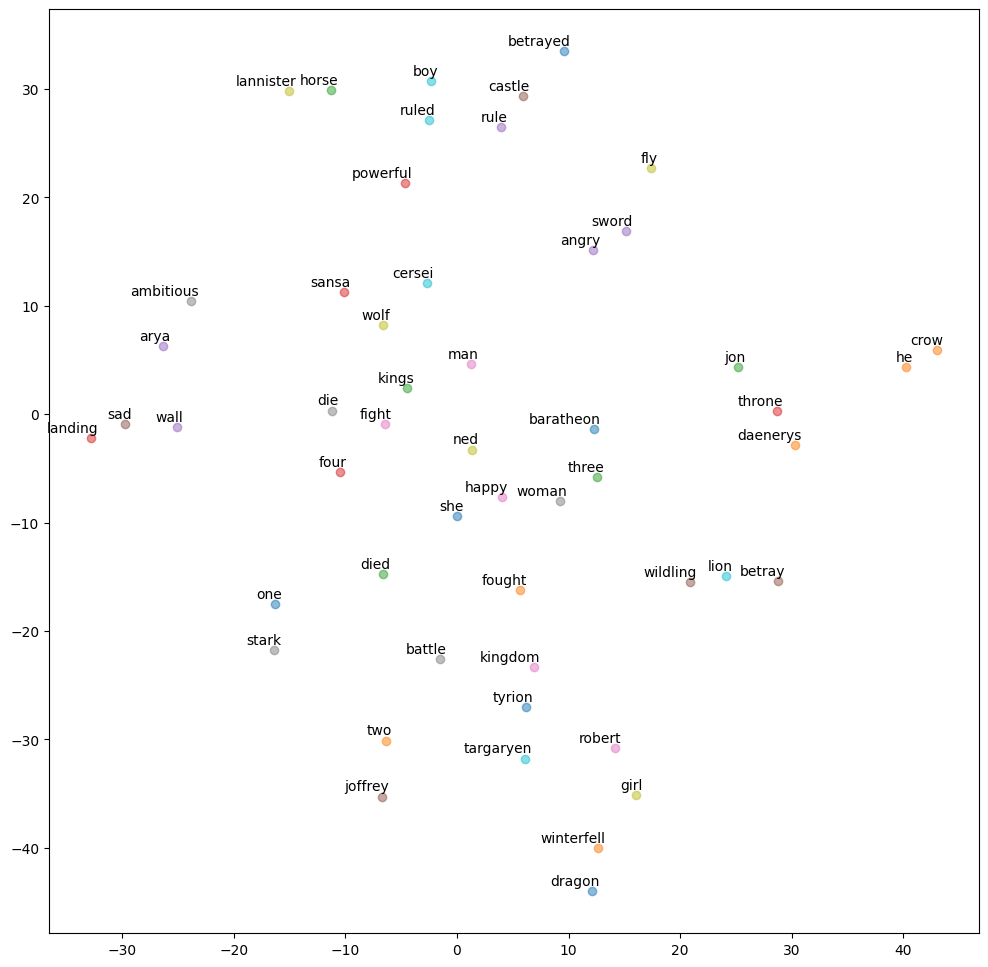

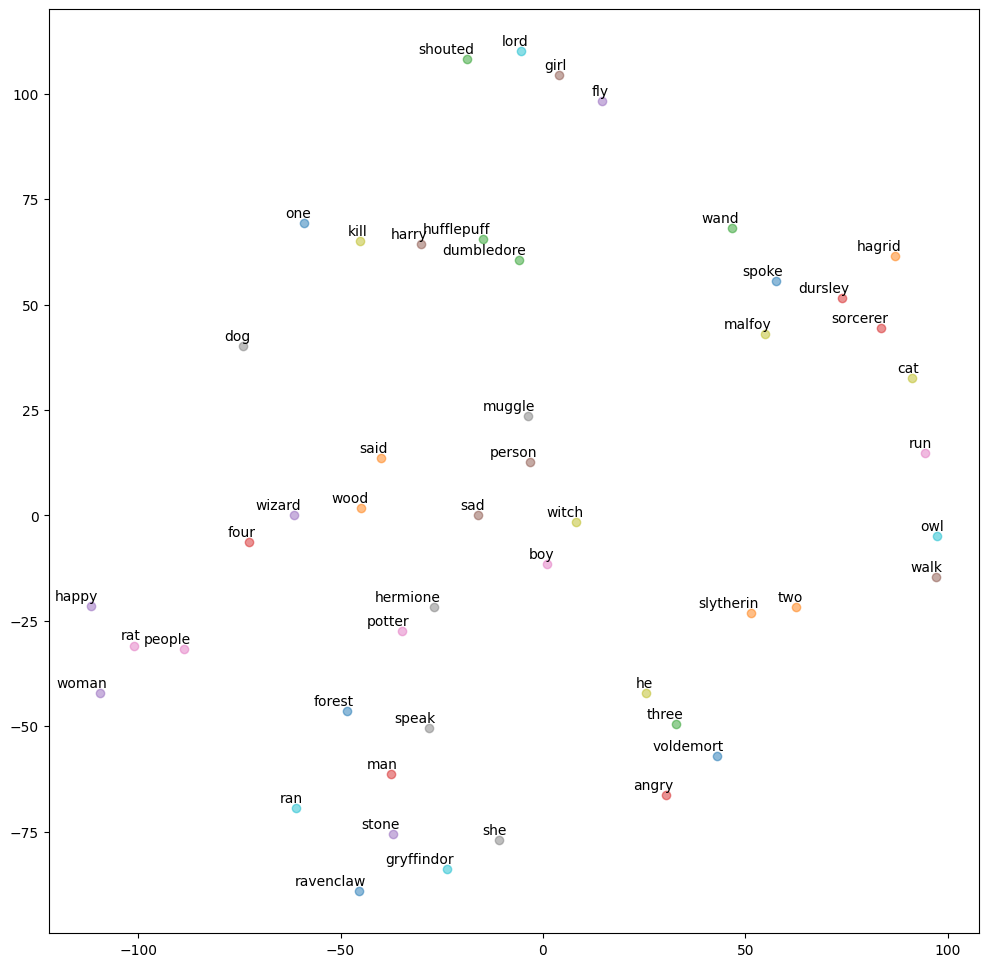

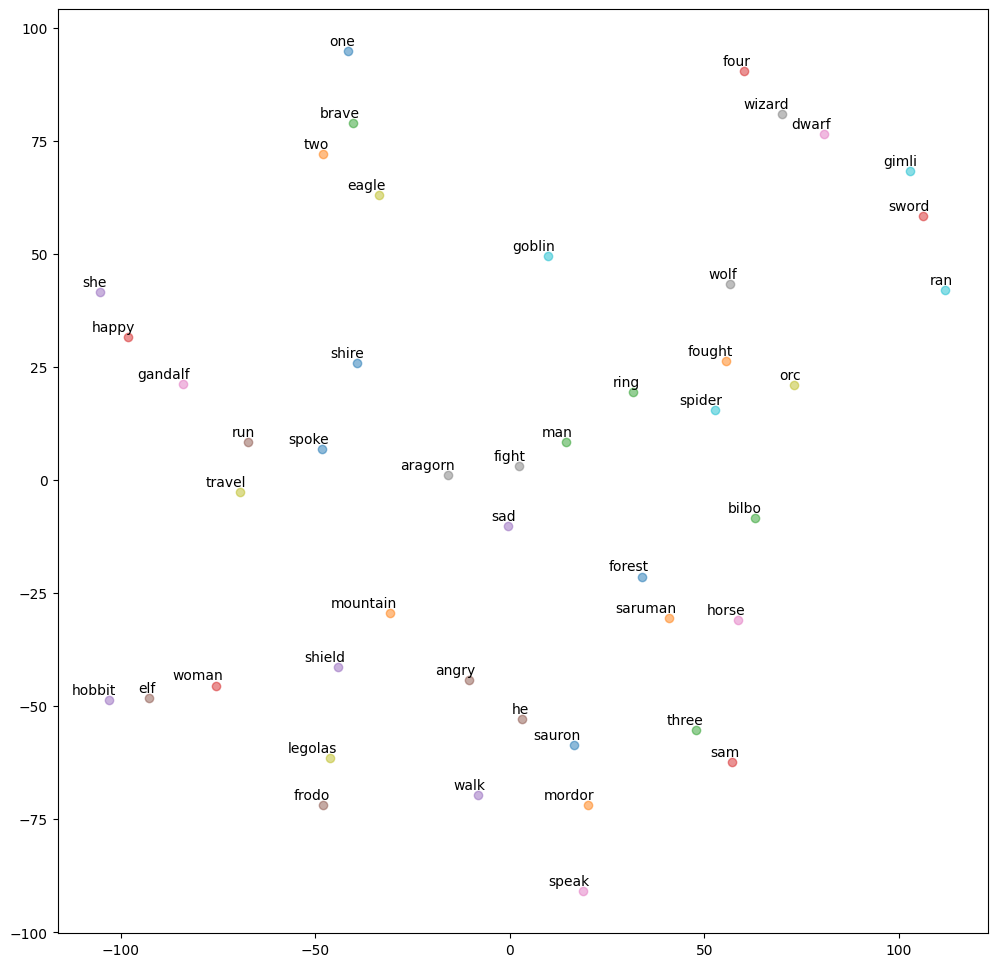

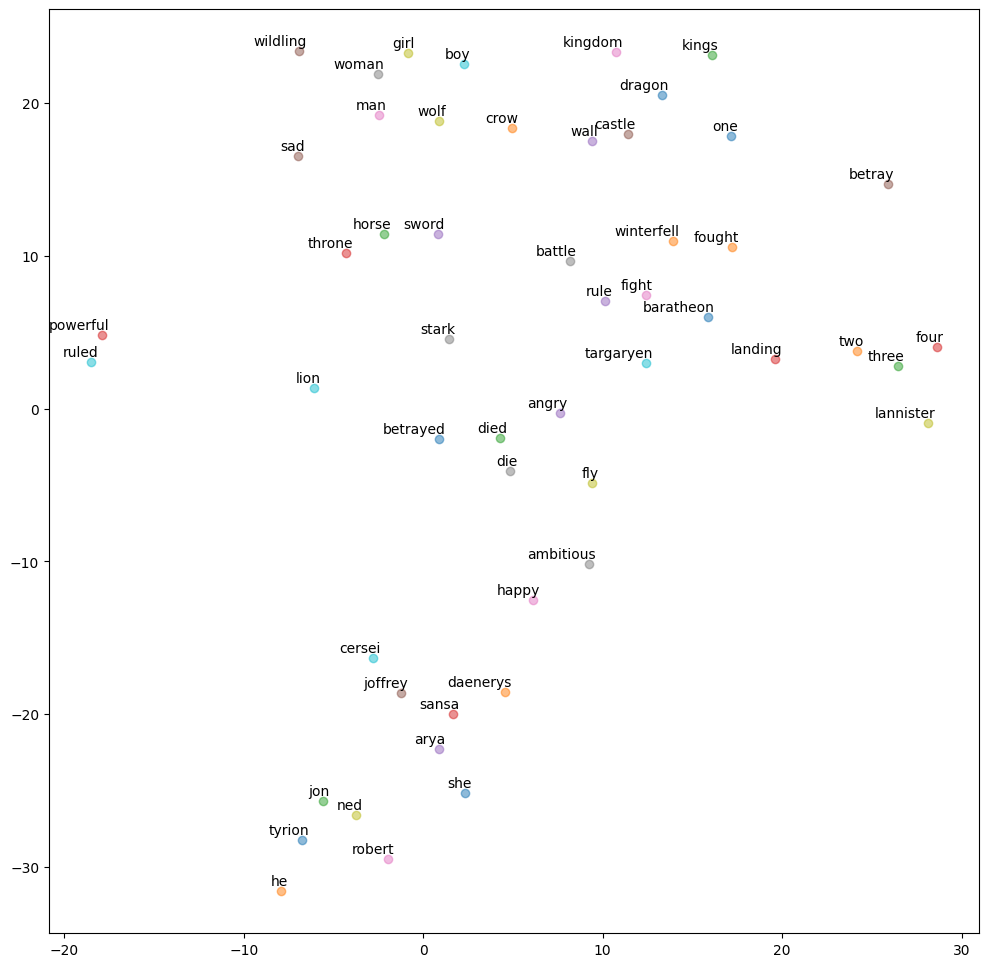

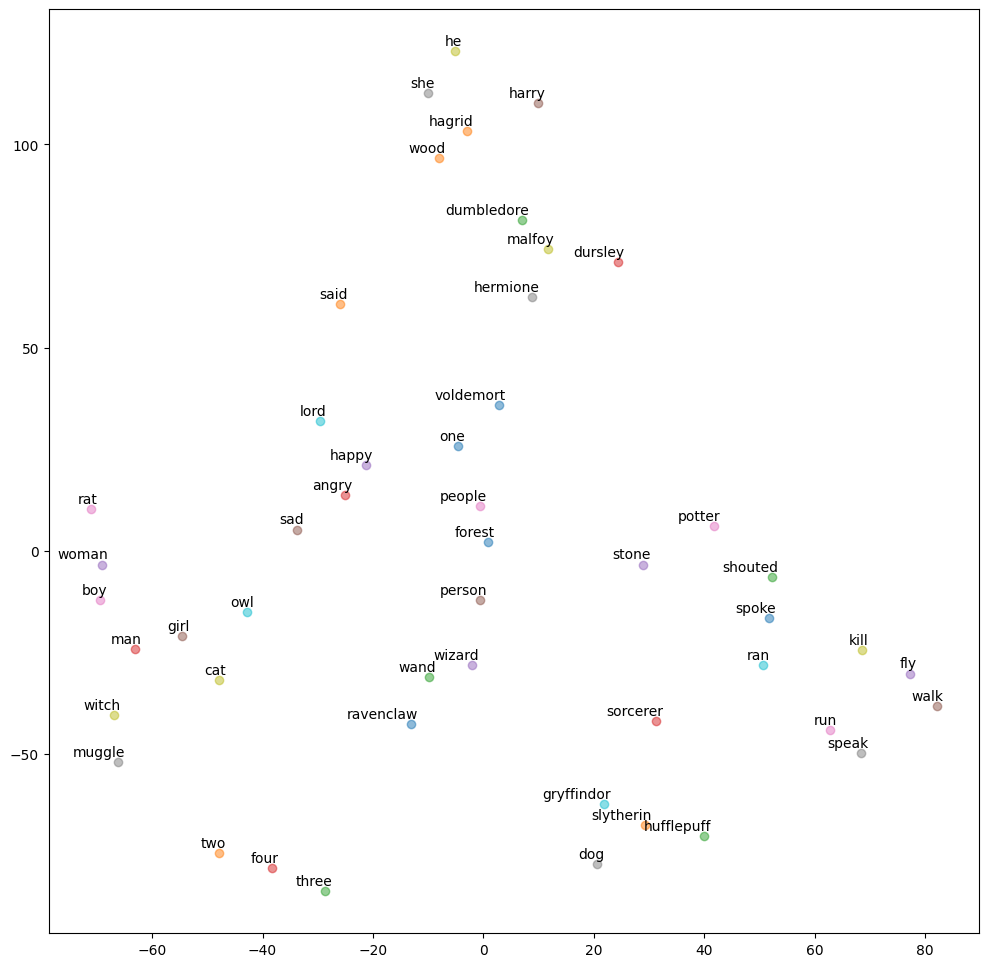

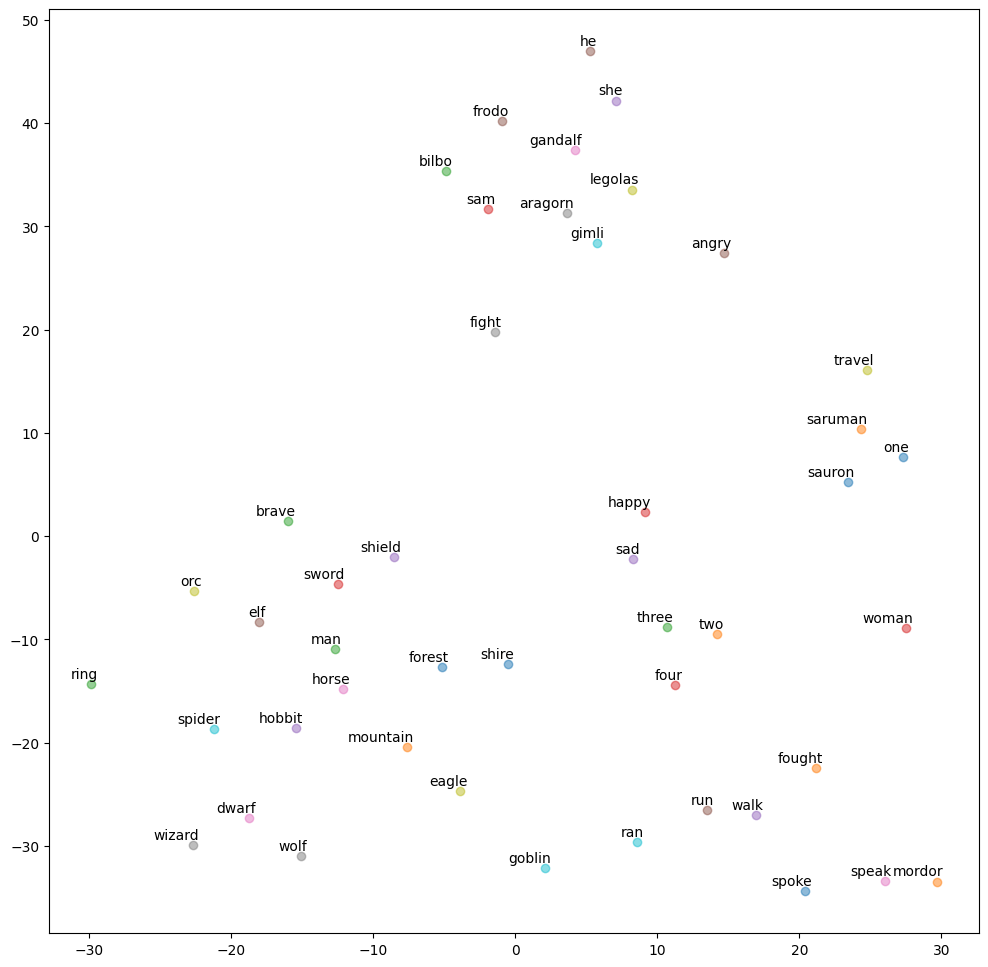

In [ ]:
paths_targets = {
    "juego de tronos": "/content/target_words_game_of_thrones.txt",
    "harry potter": "/content/target_words_harry_potter.txt",
    "el señor de los anillos": "/content/target_words_the_fellowship_of_the_ring.txt"
}

for titulo, ruta in paths_targets.items():
    words = fa.palabras_target(ruta)
    fa.visualize_all_tsne_embeddings(
        embeddings_antes_entrenar_dict[titulo],   # embeddings aún no entrenados
        word_index_dict[titulo],                    # el diccionario word -> índice
        words,                                      # palabras a visualizar
        words,                                      # palabras a etiquetar (opcional)
        None                                     # título para guardar o mostrar
    )

for titulo, ruta in paths_targets.items():
    words = fa.palabras_target(ruta)
    fa.visualize_all_tsne_embeddings(
        embeddings_despois_entrenar_dict[titulo],   # embeddings ya entrenados
        word_index_dict[titulo],                    # el diccionario word -> índice
        words,                                      # palabras a visualizar
        words,                                      # palabras a etiquetar (opcional)
        None                                      # título para guardar o mostrar
    )






In [ ]:
#similitud semántica mediante la similitud del coseno
for titulo, ruta in paths_targets.items():
    words = fa.palabras_target(ruta)
    fa.calcular_similitud_coseno(words, word_index_dict[titulo], embeddings_despois_entrenar_dict[titulo], titulo)

+------------+-----------------------------------------------------------------------------------------------------+
|   Target   |                                Palabras máis próximas juego de tronos                               |
+------------+-----------------------------------------------------------------------------------------------------+
|    one     |           casterly, thirty, rest, main, ones, fruity, ghosts, amber, pigeon, dragonknight           |
|    two     |       gorgeous, illyrio, lives, intentions, furs, encouragement, trifling, meryn, pace, along       |
|   three    |           companion, youll, wash, harvest, sigh, forty, manderly, heroes, wobbled, slaver           |
|    four    |        decent, host, smiths, councillor, formalities, cage, indigo, platform, pride, forswore       |
|    rule    |        resting, becca, refused, running, curdled, feather, suspected, staying, parapet, dirty       |
|   betray   | quarry, sheltered, rests, incomprehensible, floor

In [ ]:
###MODELO 2
input_vector_dict = {}
output_vector_dict = {}

for titulo in sequences_dict:
    input_vector, output_vector = fa.cartesian_product(sequences_dict[titulo])
    input_vector_dict[titulo] = input_vector
    output_vector_dict[titulo] = output_vector

for titulo in sequences_dict:
    print(f"--- {titulo.upper()} ---")
    print("Input vector (primeras 5 filas):")
    print(input_vector_dict[titulo][:5])
    print("Output vector (primeras 5 filas):")
    print(output_vector_dict[titulo][:5])
    print("\n")

--- JUEGO DE TRONOS ---
Input vector (primeras 5 filas):
[[    3    78]
 [    3    33]
 [    3    95]
 [    3   271]
 [    3 38589]]
Output vector (primeras 5 filas):
[1 1 1 1 0]


--- HARRY POTTER ---
Input vector (primeras 5 filas):
[[    2     7]
 [    2   123]
 [    2     1]
 [    2   631]
 [    2 61720]]
Output vector (primeras 5 filas):
[1 1 1 1 0]


--- EL SEÑOR DE LOS ANILLOS ---
Input vector (primeras 5 filas):
[[  112    64]
 [  112   163]
 [  112   362]
 [  112     3]
 [  112 12683]]
Output vector (primeras 5 filas):
[1 1 1 1 0]




In [ ]:
model_dicts = {}
embedding_size = 50 #el mismo que en la mejor arquitectura del modelo 1
# Crear 1 modelo para cada texto, igual que antes
for titulo in vocab_size_dict:
    model_dicts[titulo] = fa.crear_modelo_II(vocab_size_dict[titulo], embedding_size)
    model_dicts[titulo].summary()
    print("\n\n")

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer1        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer2        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer1    │ (None, 1, 50)     │    373,950 │ input_layer1[0][… │
│ (Embedding)         │                   │            │ input_layer2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1, 1)      │          0 │ embedding_layer1… │
│                     │                   │            │ embedding_layer1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 373,952 (1.43 MB)

 Trainable params: 373,952 (1.43 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer1        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer2        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer1    │ (None, 1, 50)     │    445,950 │ input_layer1[0][… │
│ (Embedding)         │                   │            │ input_layer2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_2 (Dot)         │ (None, 1, 1)      │          0 │ embedding_layer1… │
│                     │                   │            │ embedding_layer1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ dot_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │          2 │ flatten_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 445,952 (1.70 MB)

 Trainable params: 445,952 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
embeddings_antes_entrenar_dict = {}

for titulo, model in model_dicts.items():
    embeddings_antes_entrenar_dict[titulo] = model.get_layer('embedding_layer1').get_weights()[0]
    print(f"✅Primer Embedding antes de entrenar {titulo}: ")
    print(embeddings_antes_entrenar_dict[titulo][0])

✅Primer Embedding antes de entrenar juego de tronos: 
[ 0.00188556  0.00575955  0.03715218 -0.01867563 -0.02483956 -0.00972073
 -0.04200927 -0.00199348  0.03985408 -0.02941488  0.04393134  0.03934637
 -0.00325739  0.03147474 -0.02842732 -0.00875064  0.00987005  0.04638014
 -0.01530439 -0.02207553  0.00751384  0.02752857 -0.01906036 -0.00183052
  0.016967    0.01129931  0.01858082  0.04710032 -0.00372798 -0.04792503
  0.01586199 -0.00782882 -0.00274651  0.0306592  -0.02340584 -0.03661346
  0.00158567 -0.00922637  0.00418457 -0.04547573 -0.03491491 -0.02223566
 -0.04032922  0.04850603 -0.00727059  0.03846531 -0.02110622 -0.0303334
  0.03761077  0.00759059]
✅Primer Embedding antes de entrenar harry potter: 
[ 0.02812253  0.04114819  0.0411529   0.00636522  0.0131264   0.03435475
 -0.04029709 -0.00639951  0.02112866 -0.01551564  0.02513344 -0.04013475
 -0.01185986 -0.00480207  0.01021566 -0.00883778  0.02977539  0.02910301
  0.00567762 -0.04357432  0.01794228  0.00659154 -0.00700397  0.018

In [ ]:
# dividimos el input_vector en dos slices necesarios para pasarselos al modelo el cual tiene dos input_layer,
# ya que los pares de valores de input layer están formados por un valor (target) y otro token (el cual puede ser o no
# del contexto de la primera palabra)
for titulo in input_vector_dict:
    input_vector_dict[titulo] = (input_vector_dict[titulo][:, 0:1], input_vector_dict[titulo][:, 1:2])


In [ ]:
embeddings_despois_entrenar_dict = {}

for titulo, model in model_dicts.items():
    print(f"Entrenando modelo para {titulo}")

    model.fit([input_vector_dict[titulo][0], input_vector_dict[titulo][1]], output_vector_dict[titulo], epochs=100, validation_split=0.1, batch_size = 1024, verbose=False)
    embeddings_despois_entrenar_dict[titulo] = model.get_layer('embedding_layer1').get_weights()[0]

Entrenando modelo para juego de tronos
Entrenando modelo para harry potter
Entrenando modelo para el señor de los anillos


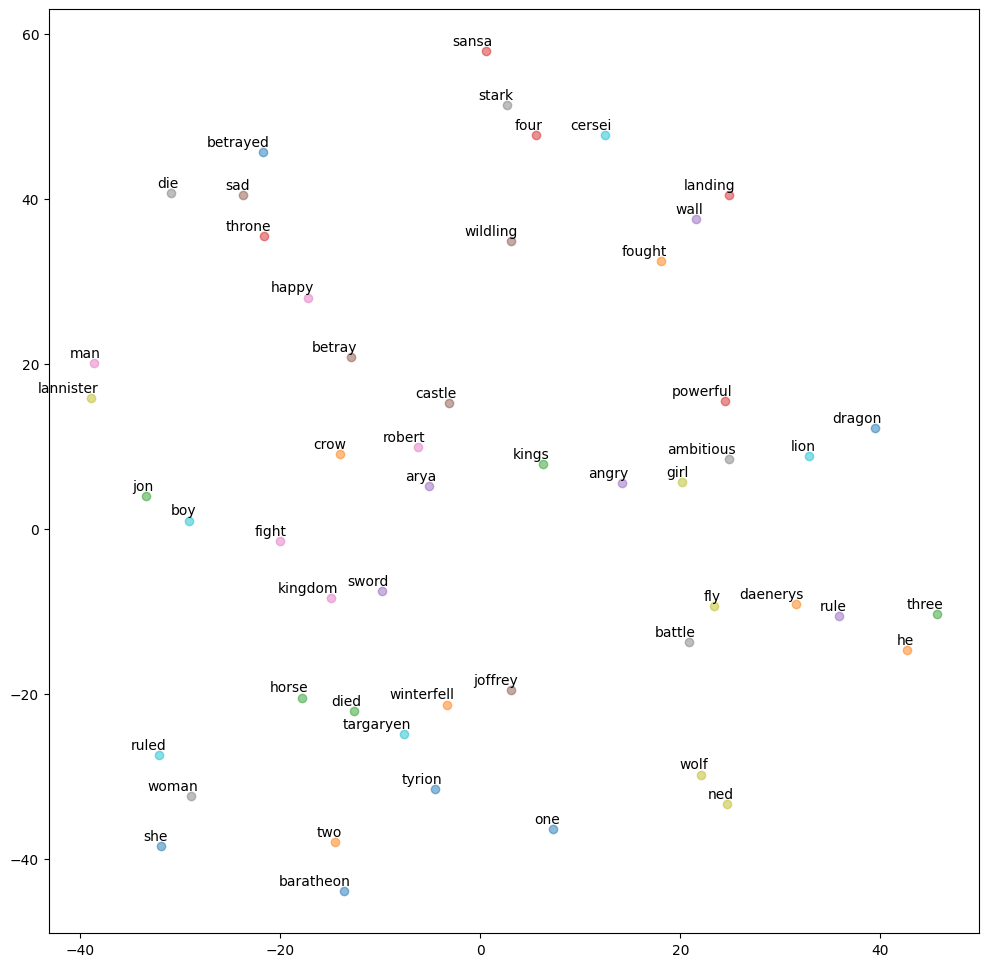

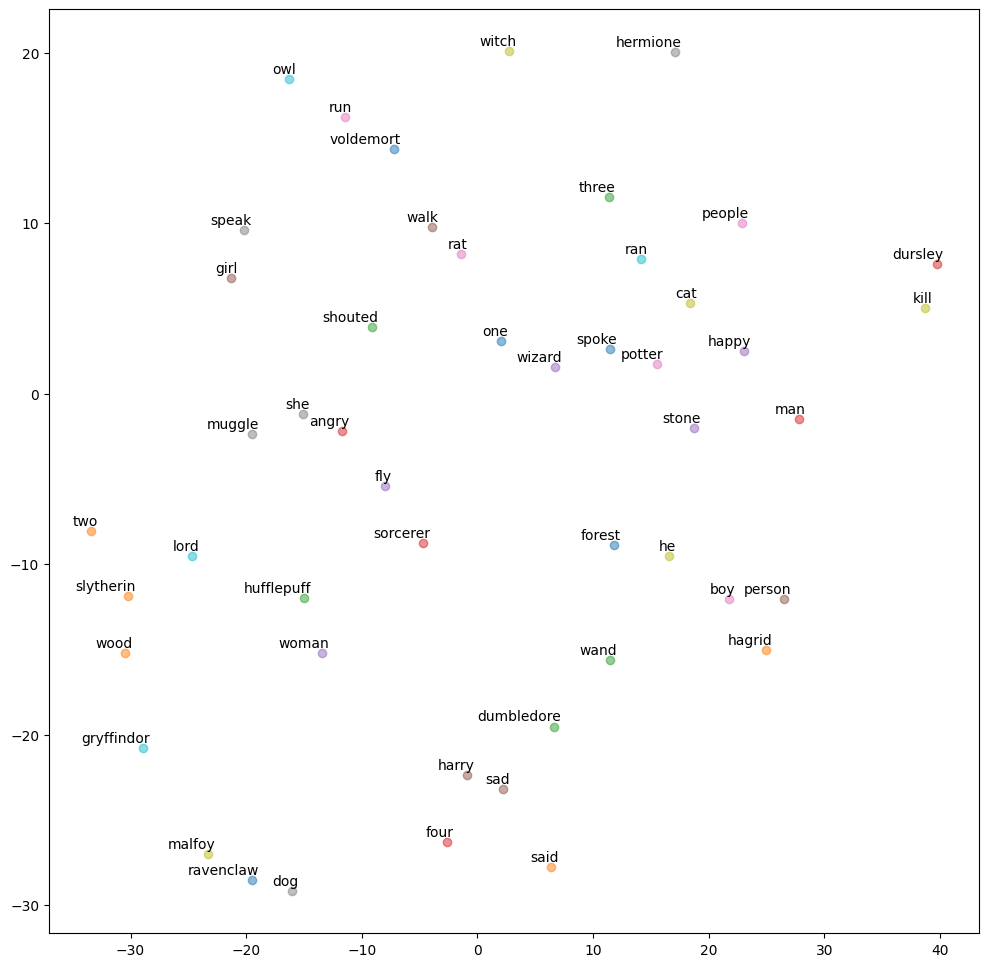

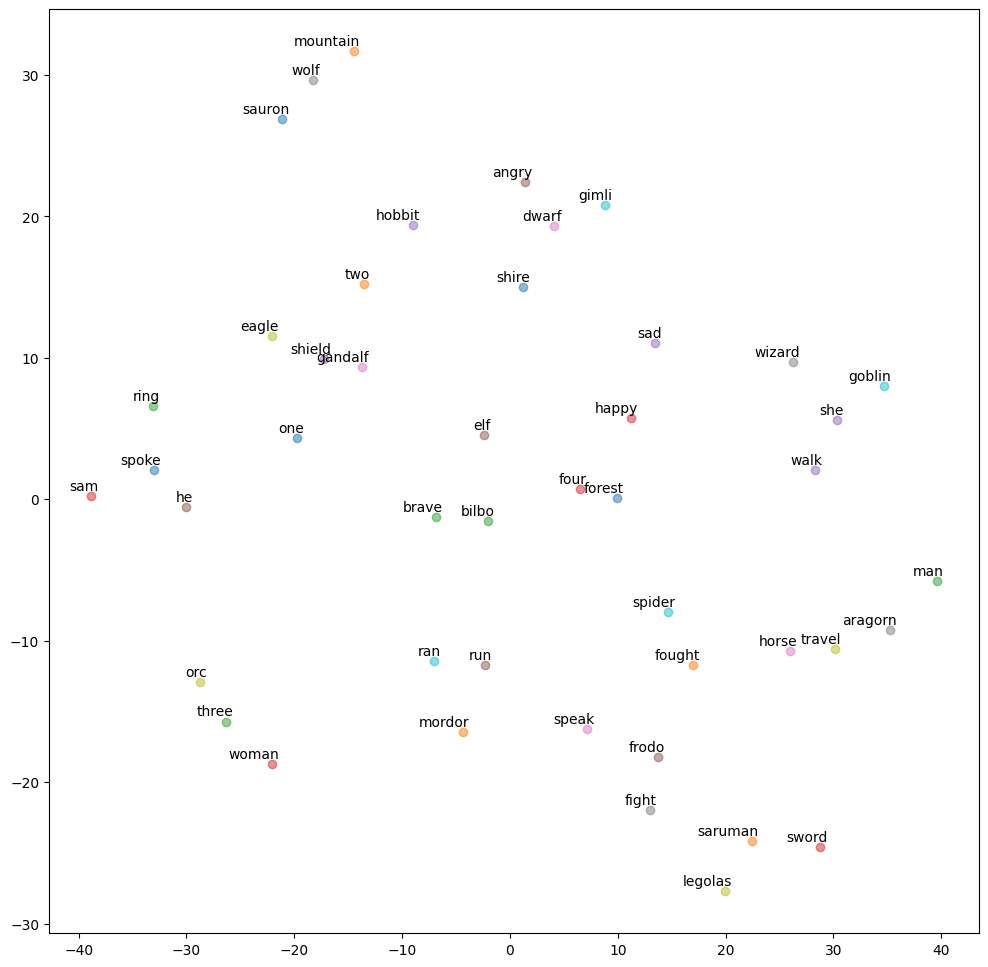

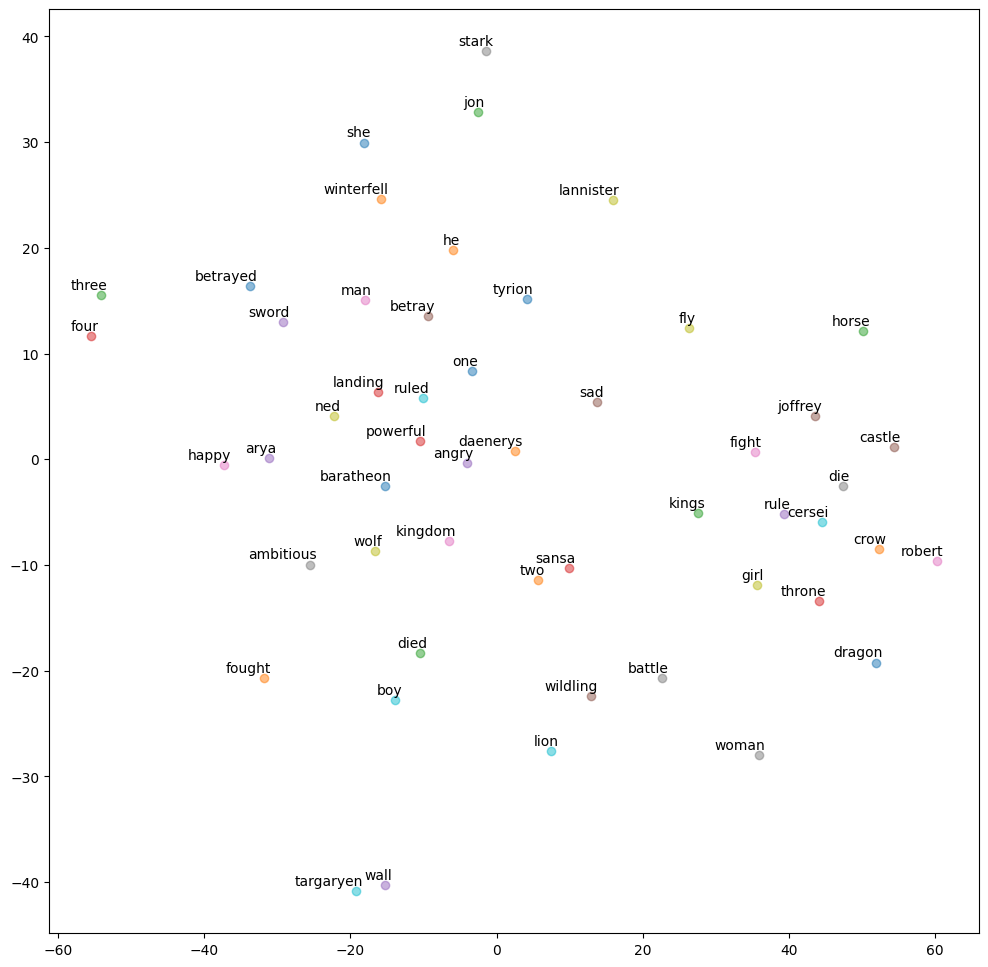

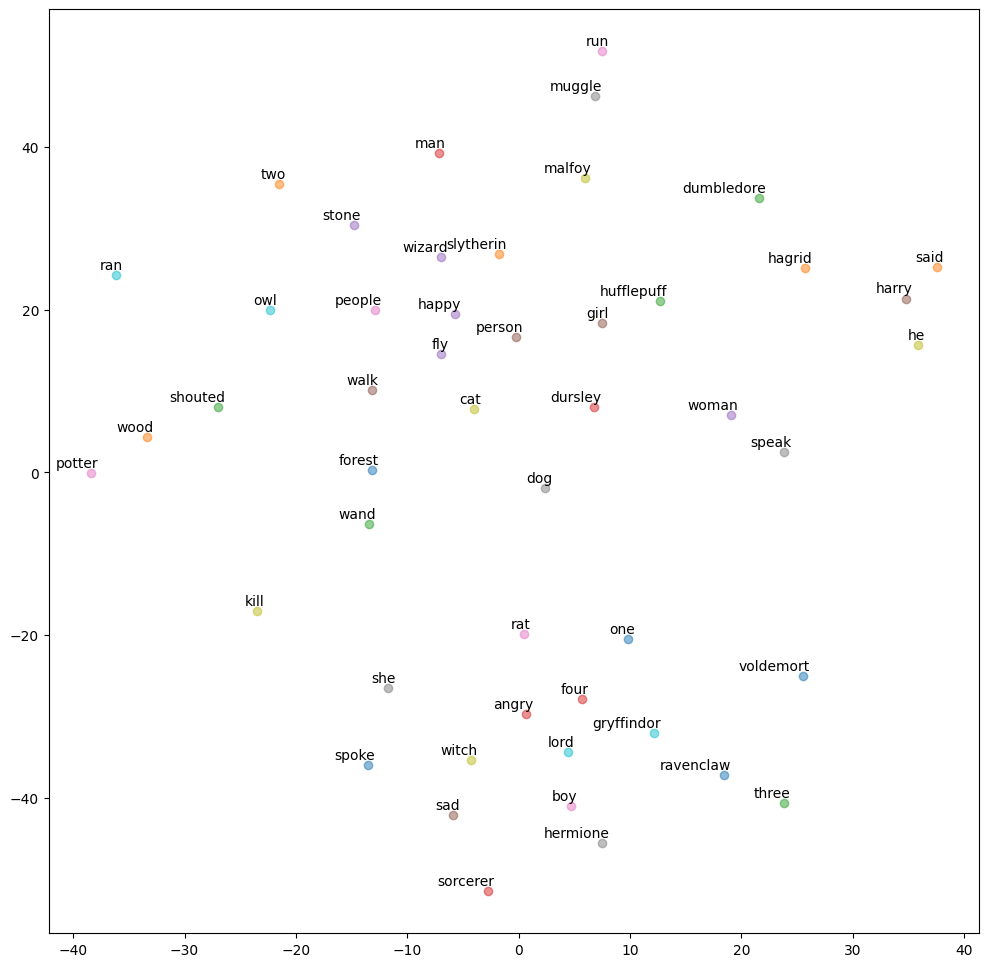

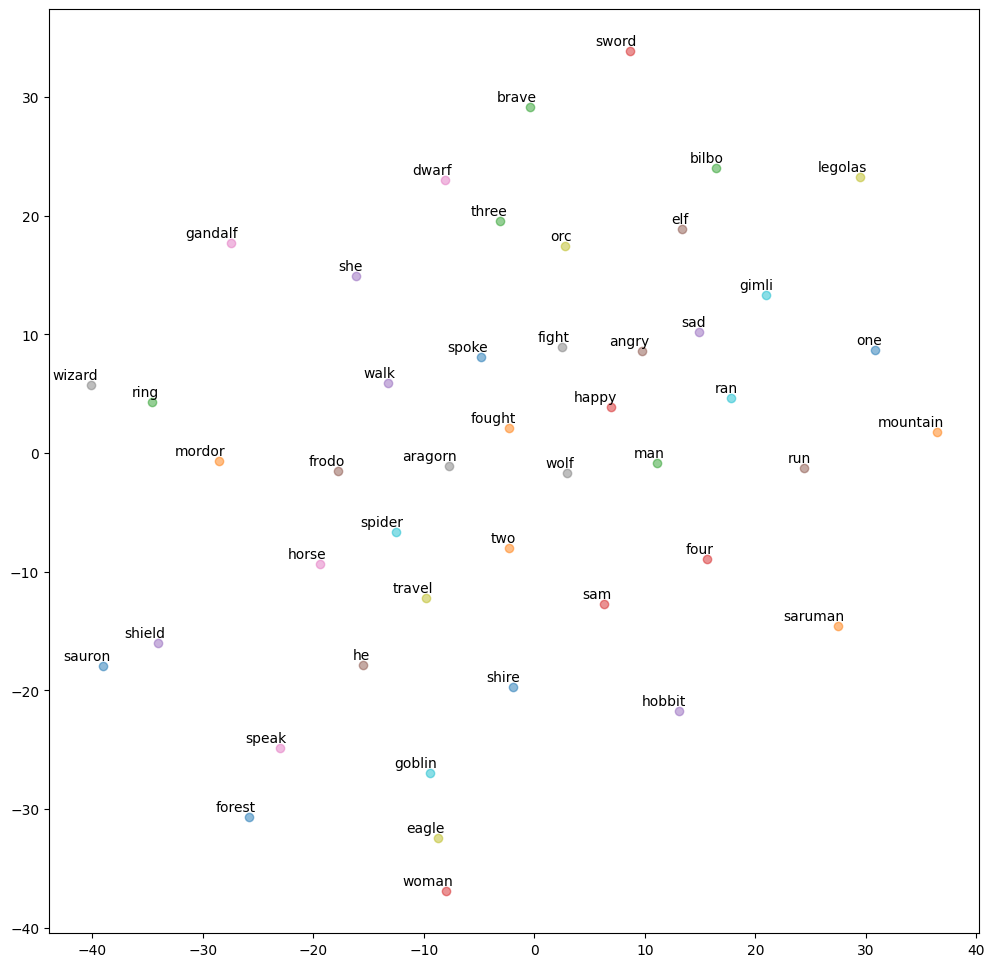

In [ ]:
paths_targets = {
    "juego de tronos": "/content/target_words_game_of_thrones.txt",
    "harry potter": "/content/target_words_harry_potter.txt",
    "el señor de los anillos": "/content/target_words_the_fellowship_of_the_ring.txt"
}

for titulo, ruta in paths_targets.items():
    words = fa.palabras_target(ruta)
    fa.visualize_all_tsne_embeddings(
        embeddings_antes_entrenar_dict[titulo],   # embeddings aún no entrenados
        word_index_dict[titulo],                    # el diccionario word -> índice
        words,                                      # palabras a visualizar
        words,                                      # palabras a etiquetar (opcional)
        None                                     # título para guardar o mostrar
    )

for titulo, ruta in paths_targets.items():
    words = fa.palabras_target(ruta)
    fa.visualize_all_tsne_embeddings(
        embeddings_despois_entrenar_dict[titulo],   # embeddings ya entrenados
        word_index_dict[titulo],                    # el diccionario word -> índice
        words,                                      # palabras a visualizar
        words,                                      # palabras a etiquetar (opcional)
        None                                      # título para guardar o mostrar
    )



In [ ]:
for titulo, ruta in paths_targets.items():
    words = fa.palabras_target(ruta)
    fa.calcular_similitud_coseno(words, word_index_dict[titulo], embeddings_despois_entrenar_dict[titulo], titulo)

+------------+------------------------------------------------------------------------------------------------+
|   Target   |                             Palabras máis próximas juego de tronos                             |
+------------+------------------------------------------------------------------------------------------------+
|    one     |    prepare, magics, spread, wispy, possibly, sincere, absolution, arthur, grimaced, journey    |
|    two     |          left, roaring, came, dared, direwolves, stiff, heard, slender, pace, eddard           |
|   three    |          speak, taken, rodrik, above, illyrio, room, coppers, continued, same, cities          |
|    four    |            above, same, rodrik, cities, coppers, illyrio, land, taken, room, speak             |
|    rule    |            common, easy, giggled, lead, office, chambers, shield, sky, shape, thank            |
|   betray   |    pouring, ryas, tray, wheelhouses, fostering, quarry, overlooked, furlined, coffers, ea